Aim of the project:

In this project we will develop a machine learning model to predict the  quality of the wine based on its organoleptic properties.

Wine quality is from 1 to 10, if quality has less than 5 is mapped as 'low', if is between 5 and 7 is mapped ad 'medium' otherwise is mapped as 'high'.

First we import the libraries and methods from Scikit-Learn and xgboost:

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier, XGBRFClassifier 
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, precision_score, recall_score
from sklearn.model_selection import learning_curve, validation_curve, train_test_split, KFold, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate, RepeatedStratifiedKFold,ParameterGrid
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from scipy.stats import loguniform, beta, uniform

from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN
from imblearn.pipeline import Pipeline as IMBPipeline
from imblearn.under_sampling import RandomUnderSampler, NearMiss

import warnings

warnings.filterwarnings('ignore')


We import dataset from Kaggle:

In [2]:
playground = pd.read_csv('winequalityN.csv')

We display the dataset and each type of value for each column:

In [3]:
playground

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [4]:
playground.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


We display missing values for each column using missingno library:

In [5]:
playground.isnull().sum(axis=0)

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

<AxesSubplot: >

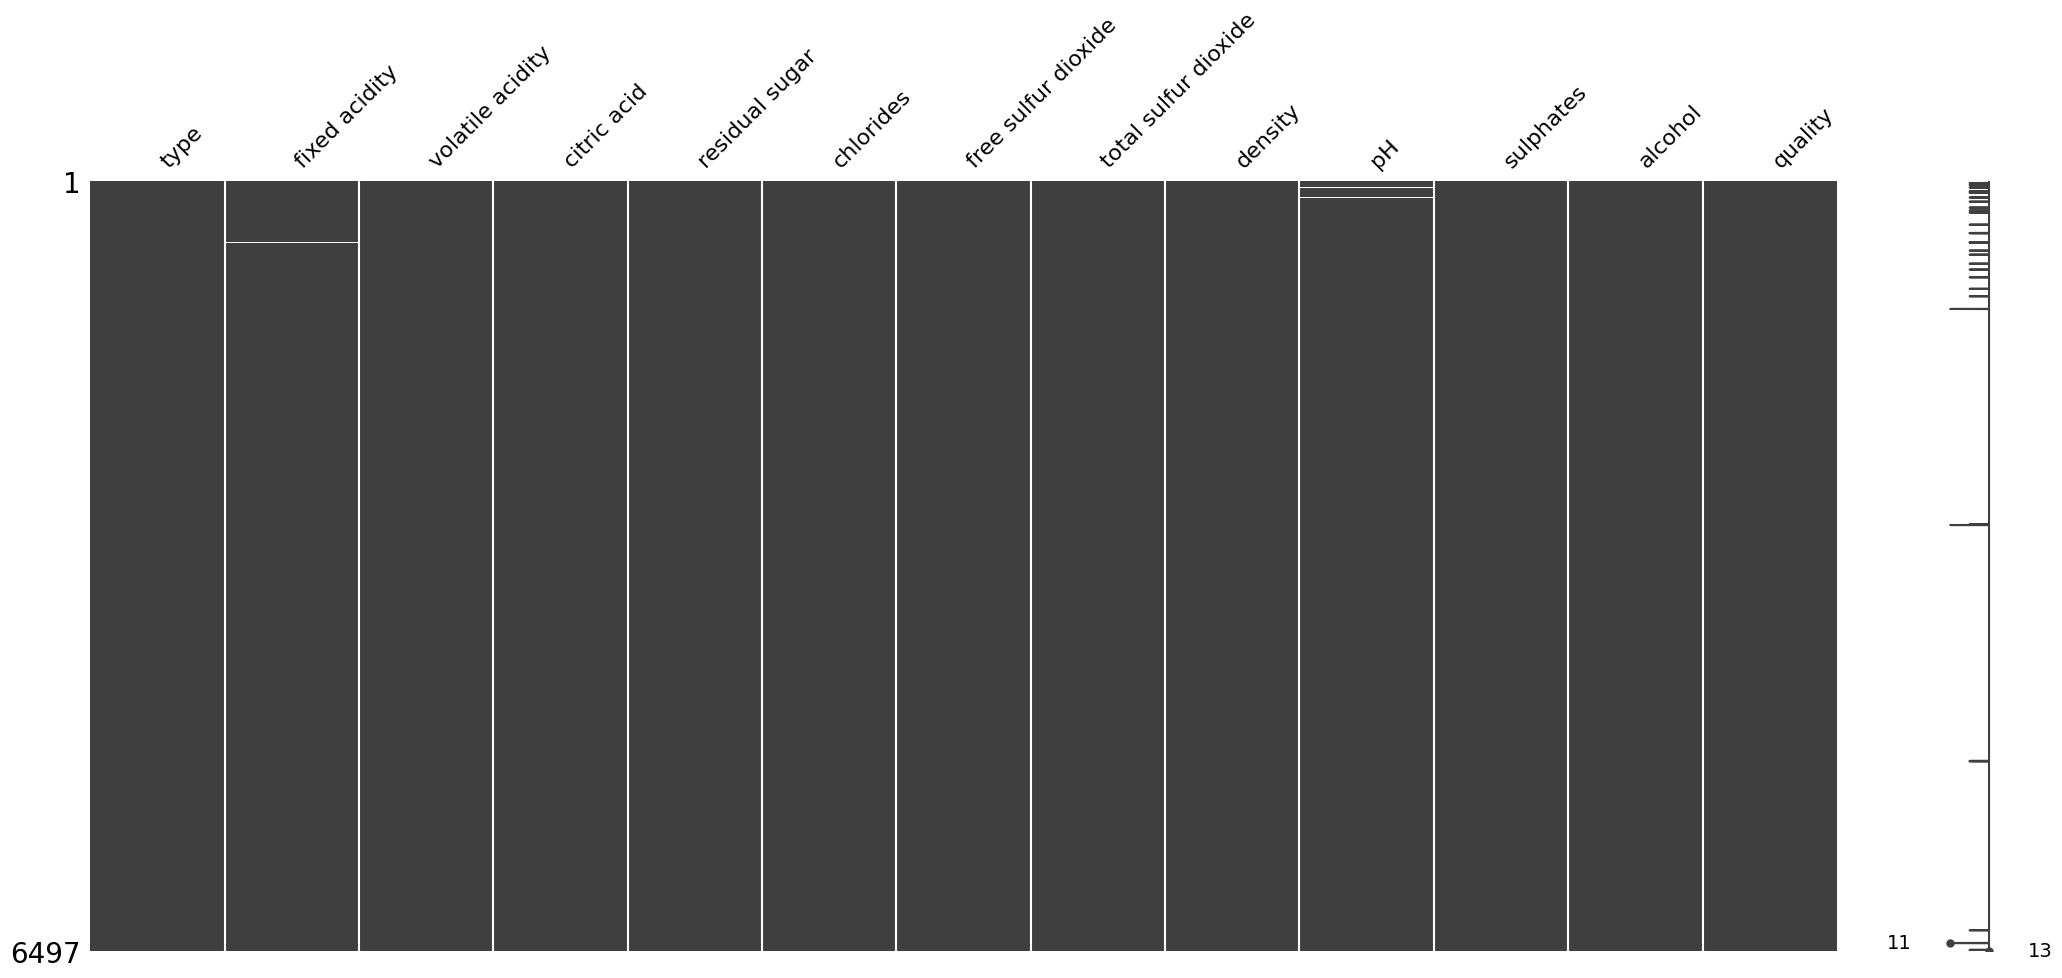

In [6]:
msno.matrix(playground)

In [7]:
df = pd.DataFrame(playground)

In [8]:
X = df

We check dataset dimension:

In [9]:
X.shape

(6497, 13)

We plot a graph with target value:

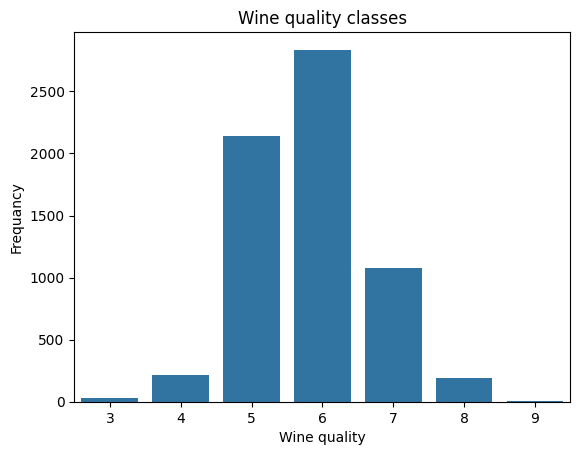

In [10]:
sns.countplot(x= df['quality'])
plt.xlabel('Wine quality')
plt.ylabel('Frequancy')
plt.title('Wine quality classes');

We map quality to have three target and we drop it from playground 

In [11]:
df['quality']=df['quality'].map({ 3:'low', 4:'low', 5:'medium', 6:'medium', 7:'medium', 8:'high', 9:'high'})
df['quality']=df['quality'].map({'low':0,'medium':1,'high':2})
X = df.drop("quality", axis=1)
y = df["quality"]

As we can see the target feature is higly imbalanced:

In [12]:
y.value_counts()

quality
1    6053
0     246
2     198
Name: count, dtype: int64

Now we plot a boxplot to view the general distribution of data across all features to check for outliers.

Outliers are extreme cases of data that may severely affect the prediction capailities of the machine learning models. Therefore, its critical that we remove them.

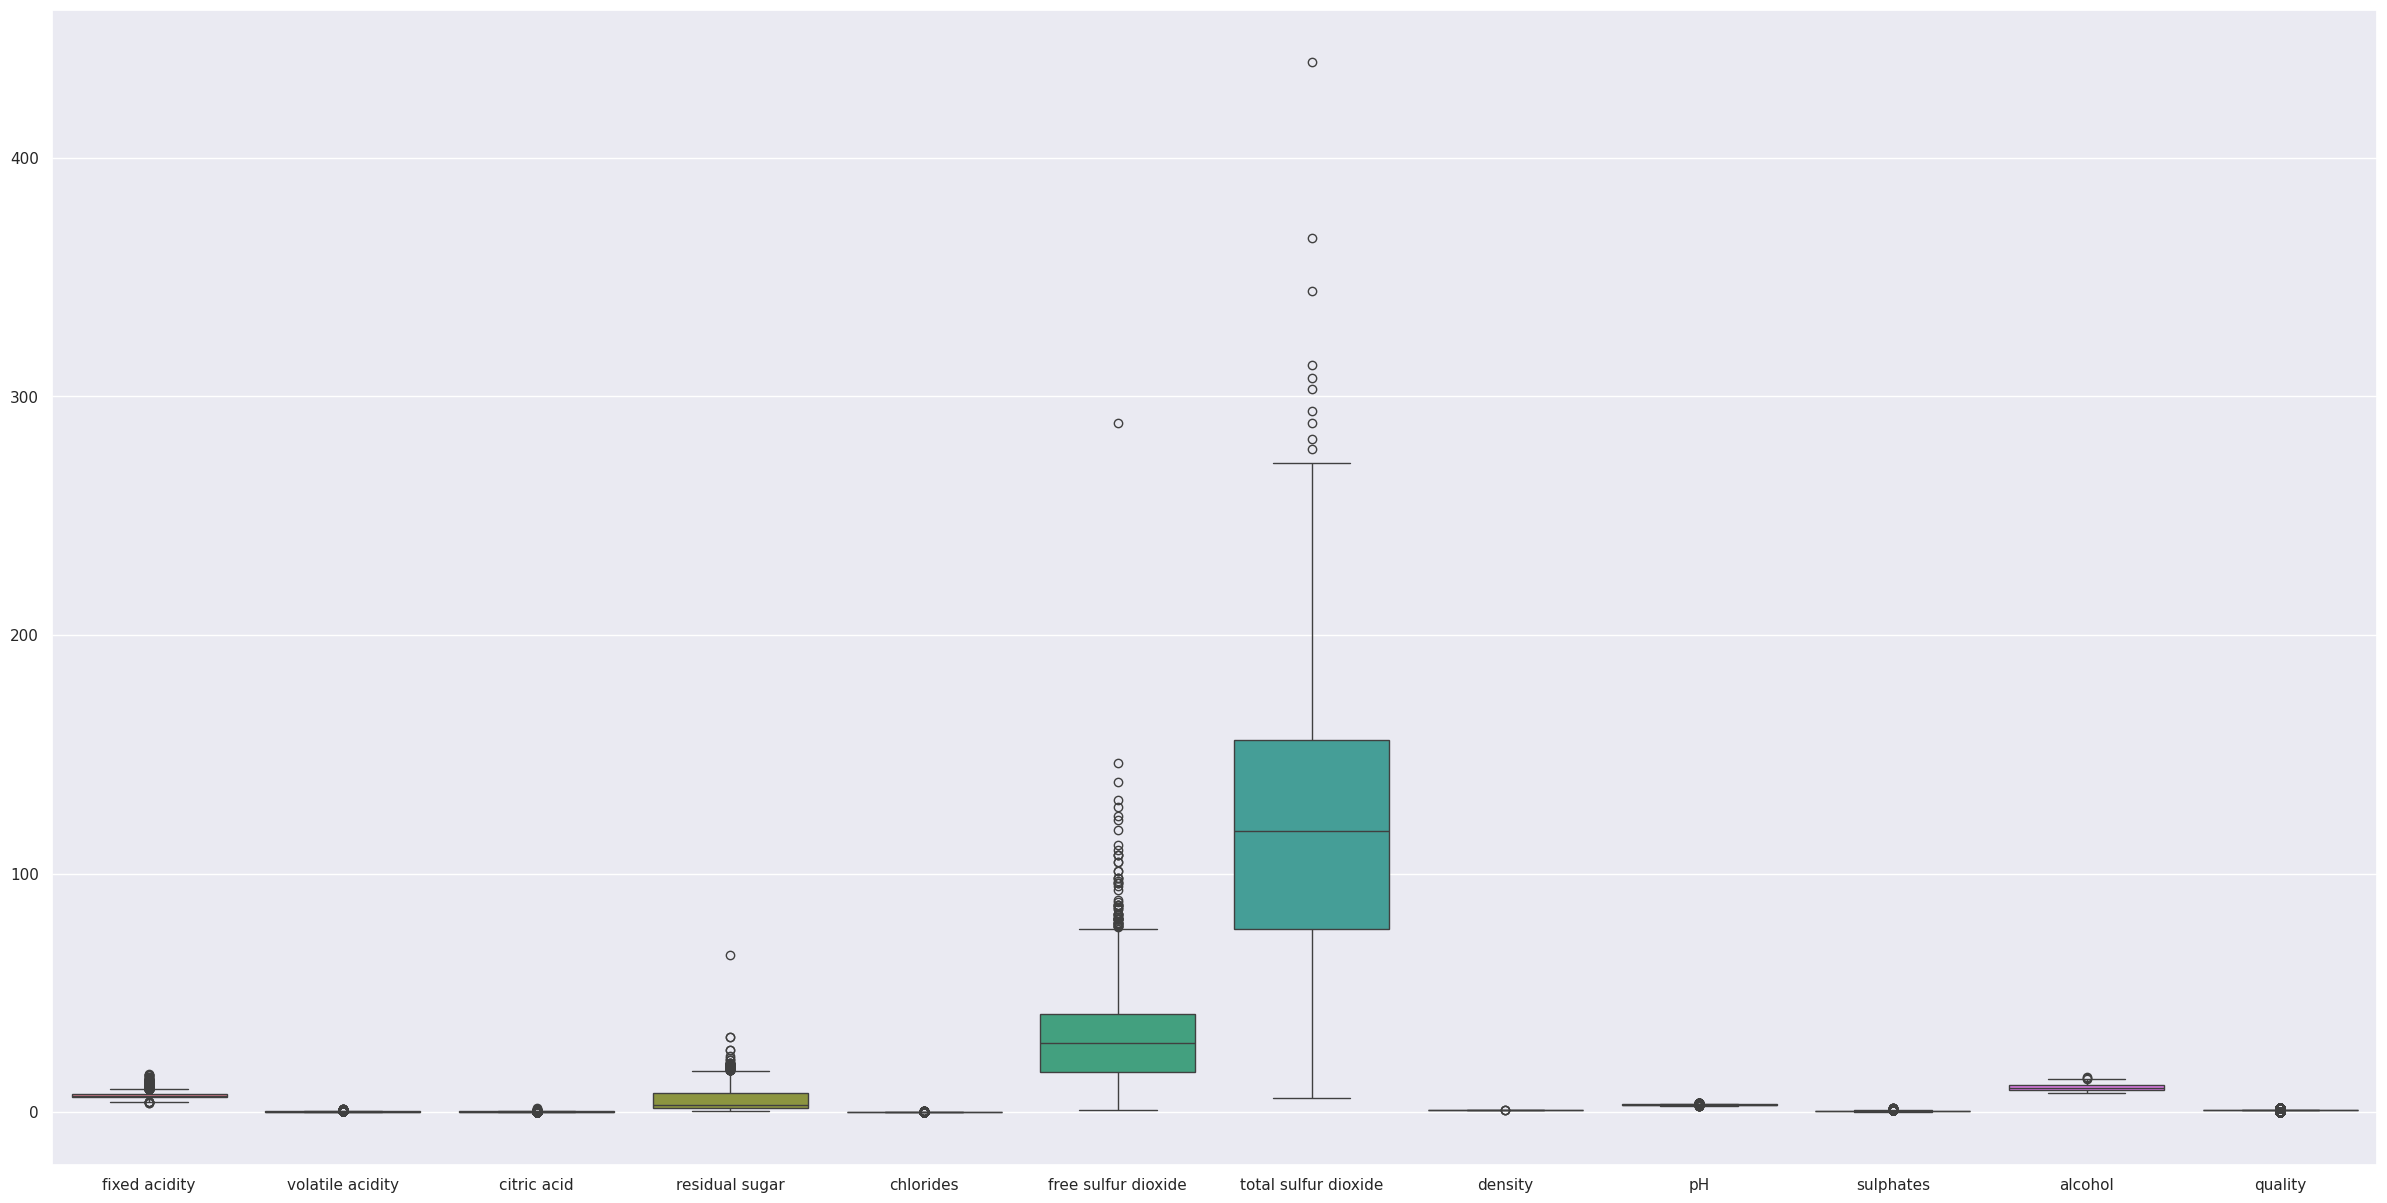

In [13]:
sns.set()
plt.figure(figsize=(30,15))
sns.boxplot(data=df)
plt.show()

As we can see residual sugar, free sulfur dioxide and total sulfur dioxide contain the largest number of outliers.

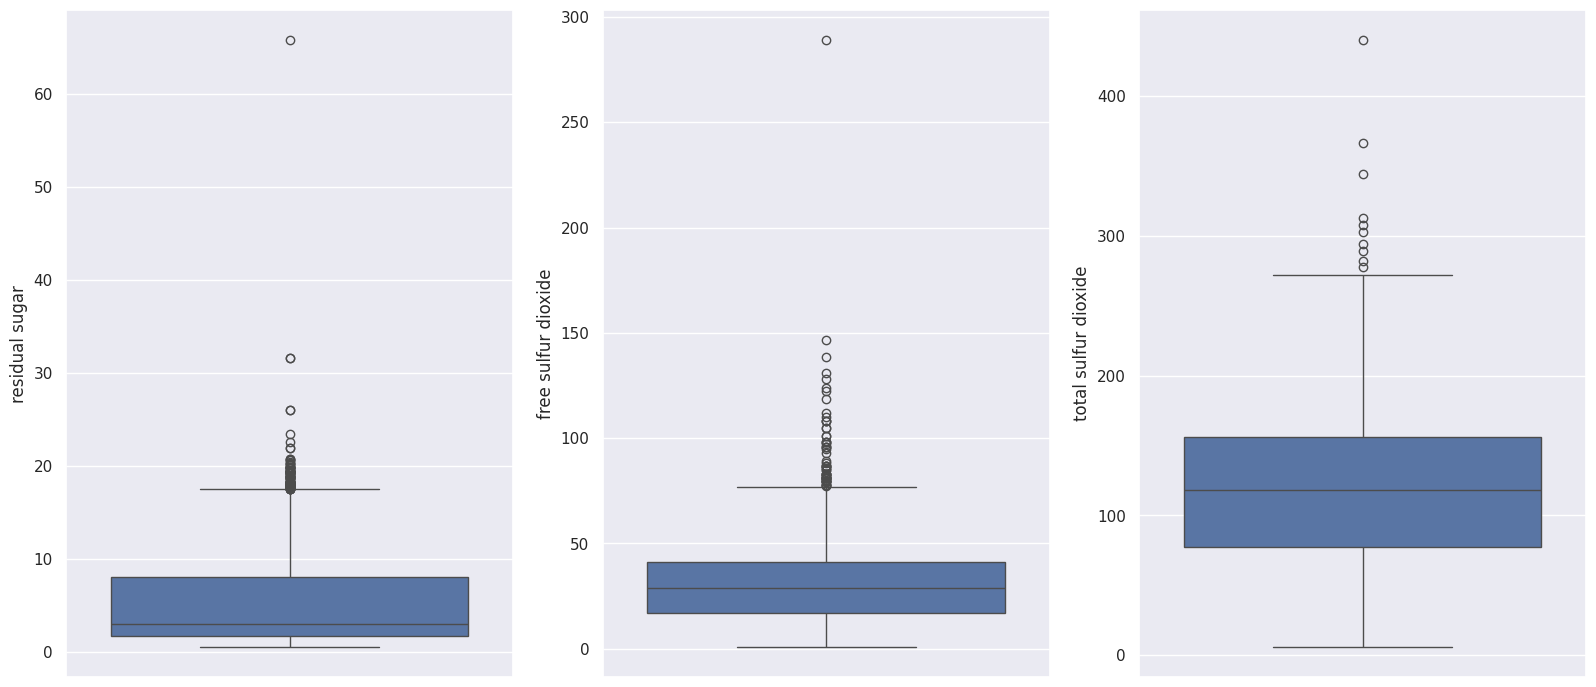

In [14]:
fig, ax =plt.subplots(1,3)
plt.subplots_adjust(right=2.5, top=1.5)
sns.boxplot(df['residual sugar'], ax=ax[0])
sns.boxplot(df['free sulfur dioxide'], ax=ax[1])
sns.boxplot(df['total sulfur dioxide'], ax=ax[2])
plt.show()

In these three columns we can notice significant outliers. Therefore, we remove them.

In [15]:
lower = df['residual sugar'].mean()-3*df['residual sugar'].std()
upper = df['residual sugar'].mean()+3*df['residual sugar'].std()
df = df[(df['residual sugar']>lower) & (df['residual sugar']<upper)]

lower = df['free sulfur dioxide'].mean()-3*df['free sulfur dioxide'].std()
upper = df['free sulfur dioxide'].mean()+3*df['free sulfur dioxide'].std()
df = df[(df['free sulfur dioxide']>lower) & (df['free sulfur dioxide']<upper)]

lower = df['total sulfur dioxide'].mean()-3*df['total sulfur dioxide'].std()
upper = df['total sulfur dioxide'].mean()+3*df['total sulfur dioxide'].std()
df = df[(df['total sulfur dioxide']>lower) & (df['total sulfur dioxide']<upper)]

We display all values of each dataset's column:

In [16]:
for column in X.columns:
    print(X[column].value_counts())
    print('-'*50)

type
white    4898
red      1599
Name: count, dtype: int64
--------------------------------------------------
fixed acidity
6.80     354
6.60     326
6.40     305
7.00     282
6.90     279
        ... 
3.90       1
3.80       1
6.45       1
4.50       1
12.10      1
Name: count, Length: 106, dtype: int64
--------------------------------------------------
volatile acidity
0.280    286
0.240    265
0.260    255
0.250    238
0.220    235
        ... 
0.975      1
1.070      1
0.950      1
1.090      1
0.905      1
Name: count, Length: 187, dtype: int64
--------------------------------------------------
citric acid
0.30    337
0.28    301
0.32    289
0.49    283
0.26    257
       ... 
1.66      1
1.23      1
0.99      1
0.88      1
0.75      1
Name: count, Length: 89, dtype: int64
--------------------------------------------------
residual sugar
2.00     235
1.80     228
1.60     223
1.40     219
1.20     195
        ... 
12.05      1
6.95       1
9.55       1
20.15      1
3.45       1
Na

We define a pipeline for each column:

SimpleImputer for columns with few missing values (with imbalanced data we use median ) and KNN for columns with more values.

OneHotEncoder for 'type', because is categorical and should be trasformed into an integer.

MinMaxScaler to standardize numerical values.

In [17]:
pipeline_group1 = Pipeline([
    ('imp', KNNImputer(n_neighbors=5) ),
    ('scaler', MinMaxScaler() )
])

pipeline_group2 = Pipeline([
    ('imp', SimpleImputer(strategy='median') ),
    ('scaler', MinMaxScaler() )
])

final_transformation = ColumnTransformer(transformers=[
    ('group1', pipeline_group1, ['fixed acidity','volatile acidity', 'pH'] ),
    ('group2', pipeline_group2, ['citric acid','residual sugar', 'chlorides', 'sulphates'] ),
    ('group4', MinMaxScaler() , ['free sulfur dioxide','total sulfur dioxide','density','alcohol'] ),
    ('group5', OneHotEncoder( categories = 'auto' ), ['type'])
],
remainder='passthrough',
verbose_feature_names_out=False,
sparse_threshold=0
)

In [18]:
dummies = pd.get_dummies(df['type'], drop_first=True)
df = pd.concat([df, dummies], axis=1)
df.drop('type', axis=1, inplace=True)

 We use heatmap to visualize the magnitude of variables across a two-dimensional space:

<AxesSubplot: >

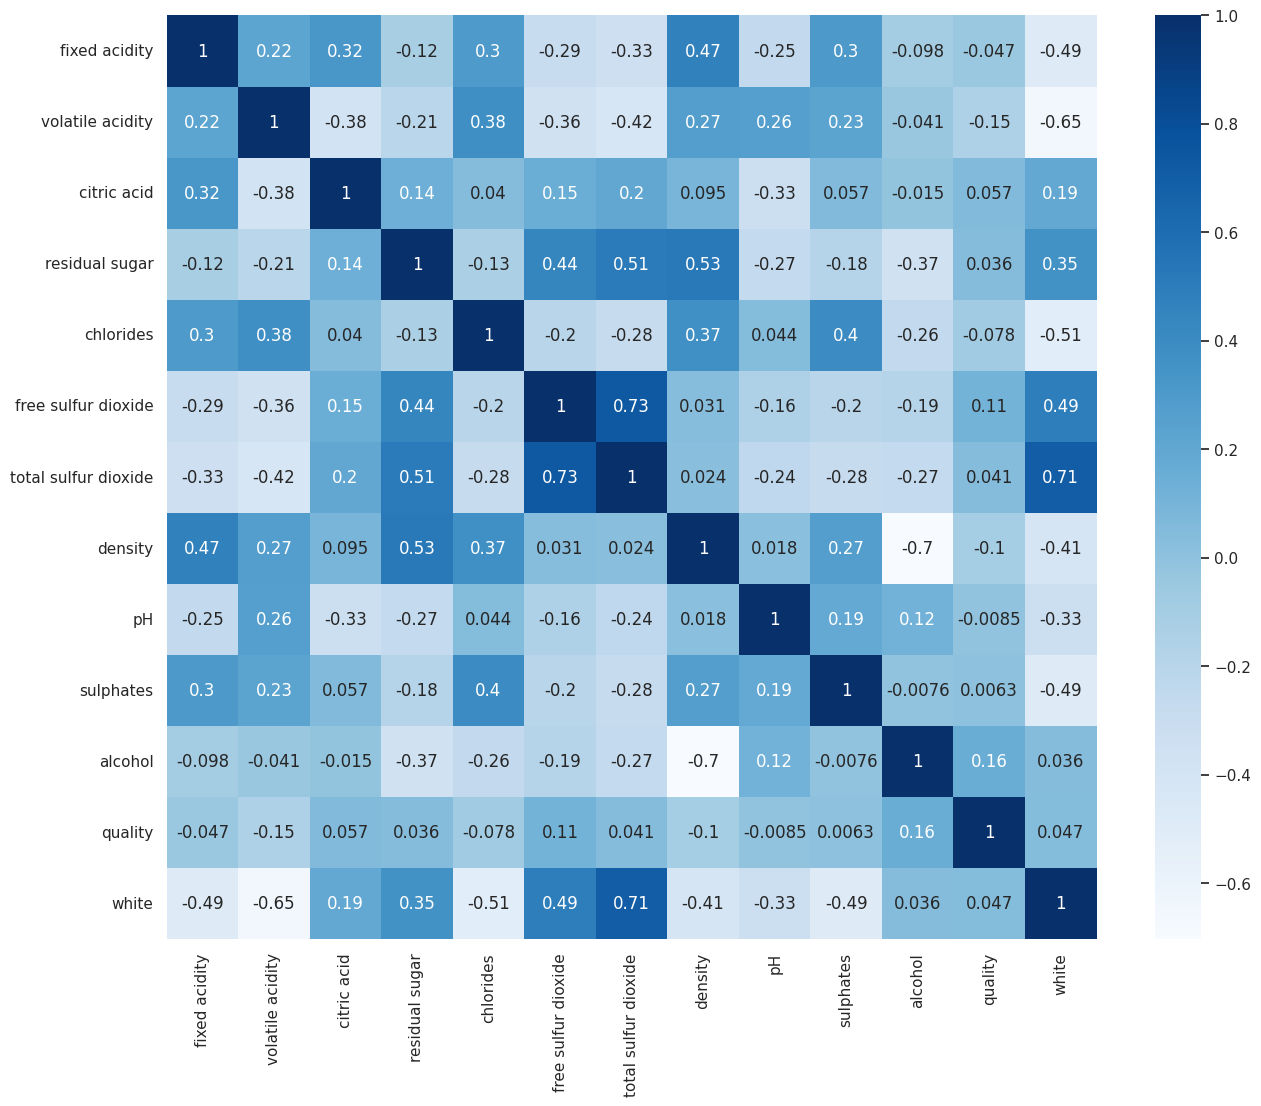

In [19]:
plt.figure(figsize=(15,12))
corr = df.corr()
sns.heatmap(corr ,annot=True , cmap= 'Blues')

We define an 
approximate IMBPipeline:

In [20]:
model_pipeline = IMBPipeline([
    ('trans', final_transformation),
    ('sampler', None),
    ('dim_reduction', None),
    ('classifier', Perceptron())
])

We split dataset into train and test sets, with test size as 20% of the dataset:

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=42, shuffle=True)

We display fit and predict to check if there are any errors :

In [22]:
model_pipeline.fit(X_train,y_train)

Pipeline(steps=[('trans',
                 ColumnTransformer(remainder='passthrough', sparse_threshold=0,
                                   transformers=[('group1',
                                                  Pipeline(steps=[('imp',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['fixed acidity',
                                                   'volatile acidity', 'pH']),
                                                 ('group2',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['citric acid',
                                                   'residual sugar',
                                                   'chlorides', 'sulphates']),
                                                 ('group4', MinMaxScaler(),
                                                  ['free sulfur dioxide',
                                                   'total sulfur dioxide',
                                                   'density', 'alcohol']),
                                                 ('group5', OneHotEncoder(),
                                                  ['type'])],
                                   verbose_feature_names_out=False)),
                ('sampler', None), ('dim_reduction', None),
                ('classifier', Perceptron())])

In [23]:
model_pipeline.predict(X_test)

array([1, 1, 1, ..., 1, 1, 1])

Since the dataset is highly unbalanced, we will test a significant number of samplers.

We set a configuration dictionary for samplers:

None  in case there is no need of a sampler with a specific estimator.

SMOTE generates synthetic samples of the minority class in an
imbalanced dataset in order to balance it.

RandomOverSampler is an algorithm that oversamples the minority class by randomly
duplicating existing samples of the minority class.

 RandomUnderSampler that is an algorithm that under-samples the majority class by randomly
removing some of the existing samples of the majority class.

ADASYN  focuses more on the samples that are difficult to classify by generating more synthetic samples around them.

NearMiss sampler  identify all pairs of samples, one from each class, that are closest to each other.
Then it removes the majority class samples that are part of these pairs:


In [24]:
sampler_configs = [
    {
        'sampler':[None]
    },
    {
        'sampler':[SMOTE(n_jobs=-1)],
        'sampler__k_neighbors' : [3, 5, 7]
    },
    {
        'sampler':[RandomOverSampler()]
    },
    {
        'sampler' : [RandomUnderSampler()]
    },
    {
        'sampler' : [ADASYN()] ,
        'sampler__n_neighbors' : [3, 5, 7]                                   
    },
    {
        'sampler' : [NearMiss()] ,
        'sampler__n_neighbors': [3, 5, 7],
        'sampler__version': [1, 2, 3]
    }

]

We set the configuration dictionary for dimentionality reducion:

None  in case there is no need of a sampler with a specific estimator.

PCA ( Principal Component Analysis) is an unsupervised dimensionality reduction technique that
 transform a set of correlated variables into a smaller set of uncorrelated variables

LDA ( Linear Discriminant Analysis) is a supervised method that find a linear combination of features that best separates two or more classes..

SFS ( Sequential Feature Selection) select a subset of features
 from a larger set to maximize the performance of a predictive model:

In [25]:
dim_reduction_configs = [
    {
        'dim_reduction': [None]
    },
    {
        'dim_reduction': [PCA()],
        'dim_reduction__n_components': [0.5, 0.7, 0.9]
    },
    {
        'dim_reduction': [LDA()]
    },
    {
        'dim_reduction': [SFS(estimator=Perceptron(), cv = None, scoring = 'f1_weighted')],
        'dim_reduction__estimator': [Perceptron(), LogisticRegression()],
        'dim_reduction__k_features' : [5,7,10]  
    }
]

We set the dictionary for classifiers:

KNeighborsClassifier classifies unseen data points based on the majority class among its knearest neighbors.

RandomForestClassifier is an ensemble method that involves training multiple decision trees
and combining their predictions to form a stronger model.

ADABoostClassifier is an ensemble method that trains a sequence of weak learners and
combines their predictions to form a stronger model.

 SVC (Support Vector Classifier) is a support vector machine that find the hyperplane that best separates different classes in the feature space, maximizing the margin between the closest points of the classes (support vectors).

DecisionTreeClassifier recursively divides the feature space into smaller regions based on
the input features, creating decision regions with the same label.

XGBoostClassifier trains a sequence of decision trees and combines their predictions to form a
stronger model.

 XGBRFClassifier is an hybrid of XGBoost and Random Forest algorithms:

In [ ]:
classifier_configs = [
      
    {
         'classifier': [KNeighborsClassifier()],
         'classifier__n_neighbors': [3,5,7,9,11,13]
    },
    {
        'classifier' : [RandomForestClassifier()],
        'classifier__n_estimators' : [1,5,10],
        'classifier__max_features': [None, 1, 2, 3],
        'classifier__max_depth' : [None, 1, 2, 3, 4, 5, 9]
    },
    {
        'classifier'  : [AdaBoostClassifier()],
        'classifier__base_estimator' : [DecisionTreeClassifier(
                                   criterion    = 'entropy' ,  
                                          max_depth    = 3
                                      ) ,
                                      RandomForestClassifier(
                                          n_estimators = 10 , 
                                          max_depth    = 3 ,  
                                          max_features = 3
                                      )] ,
        'classifier__n_estimators' : [10, 50, 100],
        'classifier__learning_rate': loguniform(0.001, 0.05)
    }, 
    {
        'classifier' : [SVC()],
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel' : ['linear', 'poly', 'rbf', 'sigmoid'],
        'classifier__decision_function_shape' : ['ovo', 'ovr']
    },

    {
        'classifier': [XGBClassifier()],
        'classifier__n_estimators': [100,200, 500],
        'classifier__learning_rate': loguniform(0.001, 0.05),  
        'classifier__max_depth' : [None, 1, 2, 3],
        'classifier__multi':['softmax','softprob']              
    }

]

We set all possible conbinations with itertools.product method:

In [27]:
all_configs = [dict(itertools.chain(*(e.items() 
for e in configuration))) 
for configuration in 
itertools.product(sampler_configs,dim_reduction_configs,classifier_configs)]

We visualize all possible combination between  sampler, dim_reduction and classifier:

In [28]:
f'Number of all possible configurations: {len(all_configs)}'

'Number of all possible configurations: 168'

In [29]:
all_configs[:2]

[{'sampler': [None],
  'dim_reduction': [None],
  'classifier': [KNeighborsClassifier()],
  'classifier__n_neighbors': [3, 5, 7, 9, 11, 13]},
 {'sampler': [None],
  'dim_reduction': [None],
  'classifier': [RandomForestClassifier()],
  'classifier__n_estimators': [1, 5, 10],
  'classifier__max_features': [None, 1, 2, 3],
  'classifier__max_depth': [None, 1, 2, 3, 4, 5, 9]}]

We run RandomizedSearchCV to perform randomized search for hyperparameter tuning:

Since we have an imbalanced multiclass target we use 'weighted' as average of F1

In [30]:
rs = RandomizedSearchCV(model_pipeline,
    param_distributions=all_configs,
    n_iter=len(all_configs) * 5,
    n_jobs=-1,
    cv = 5,
    scoring='f1_weighted'
)

We set a limit to the number of possible configurations to reduce the computation time:

In [31]:
if len(all_configs)<100:
    iteration_number = 100
else:
    iteration_number = len(all_configs)

With cross validation we find the performance of all possible configuration:

In [ ]:
scores = cross_validate(rs, X_train, y_train, scoring='f1_weighted',  cv = 5, return_estimator=True, verbose=3, error_score='raise')

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


We visualize the best estimators and their performance on test set:

In [ ]:
for index, estimator in enumerate(scores['estimator']):
    print(estimator.best_estimator_.get_params()['sampler'])
    print(estimator.best_estimator_.get_params()['dim_reduction'])
    print(estimator.best_estimator_.get_params()['classifier'],estimator.best_estimator_.get_params()['classifier'].get_params())
    print(scores['test_score'][index])
    print('-'*10)

None
None
RandomForestClassifier(max_features=3, n_estimators=10) {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 3, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 10, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
0.9132058253255939
----------
RandomOverSampler()
None
RandomForestClassifier(max_features=1, n_estimators=10) {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 1, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 10, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
0.9247022002626537
----------
RandomOverSampler()

We display performance of classifiers on train and test:

In [ ]:
for estimator in scores['estimator']:
    pred_train = estimator.best_estimator_.fit(X_train, y_train)
    pred_train = estimator.best_estimator_.predict(X_train)
    pred_test = estimator.best_estimator_.predict(X_test)
    f1_train = f1_score(y_train, pred_train, average = 'weighted')
    f1_test = f1_score(y_test, pred_test, average = 'weighted')
    print(f'F1 on training set:{f1_train}, F1 on test set:{f1_test}')

F1 on training set:0.9935064692837245, F1 on test set:0.9320101490131856
F1 on training set:0.999616094657718, F1 on test set:0.9258448692325211
F1 on training set:0.9990418291964307, F1 on test set:0.9246305702677481
F1 on training set:0.9918633072356899, F1 on test set:0.9273289440786733
F1 on training set:0.9986598202525687, F1 on test set:0.9266502859543782


We display the best estimator found with cross validation (In this case we have taken the least underfitted):

In [ ]:
best_model_pipeline = IMBPipeline([
    ('trans', final_transformation),
    ('sampler', None),
    ('dim_reduction',PCA(n_components=0.9)),
    ('classifier', XGBClassifier(n_estimators=200,learning_rate=0.012597166913529382,multi='softprob'))   
])

In [ ]:
params = {}

In [ ]:
rs_best = RandomizedSearchCV(
    estimator = best_model_pipeline,
    param_distributions = params,
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3),
    n_iter=100,
    scoring='f1_weighted'
)

We display fit of best estimator to check any error :

In [ ]:
rs_best.fit(X_train, y_train)

RandomizedSearchCV(cv=RepeatedStratifiedKFold(n_repeats=3, n_splits=5, random_state=None),
                   estimator=Pipeline(steps=[('trans',
                                              ColumnTransformer(remainder='passthrough',
                                                                sparse_threshold=0,
                                                                transformers=[('group1',
                                                                               Pipeline(steps=[('imp',
                                                                                                KNNImputer()),
                                                                                               ('scaler',
                                                                                                MinMaxScaler())]),
                                                                               ['fixed '
                                                                                'acidity',
                                                                                'volatile '
                                                                                'acidity',
                                                                                'pH']),
                                                                              ('group2',
                                                                               Pipeline(steps=[('imp'...
                                                            learning_rate=0.012597166913529382,
                                                            max_bin=None,
                                                            max_cat_threshold=None,
                                                            max_cat_to_onehot=None,
                                                            max_delta_step=None,
                                                            max_depth=None,
                                                            max_leaves=None,
                                                            min_child_weight=None,
                                                            missing=nan,
                                                            monotone_constraints=None,
                                                            multi='softprob',
                                                            multi_strategy=None,
                                                            n_estimators=200,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=100, param_distributions={}, scoring='f1_weighted')

In [ ]:
rs_best.best_estimator_

Pipeline(steps=[('trans',
                 ColumnTransformer(remainder='passthrough', sparse_threshold=0,
                                   transformers=[('group1',
                                                  Pipeline(steps=[('imp',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['fixed acidity',
                                                   'volatile acidity', 'pH']),
                                                 ('group2',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['citric acid',
                                                   'residual sugar',
                                                   'chloride...
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.012597166913529382, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=None,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi='softprob', multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
best_estimator = estimator.best_estimator_
y_predicted = best_estimator.predict(X_test)

We evaluate precision and recall score:

In [ ]:
precision_score(y_test, best_estimator.predict(X_test), average = 'weighted')

0.9243451908915827

In [ ]:
recall_score(y_test, best_estimator.predict(X_test), average = 'weighted')

0.9384615384615385

We evaluate f1_score (a trade-off between precision and reacall) on the test set:

In [ ]:
f1_score(y_test, rs_best.best_estimator_.predict(X_test), average='weighted')

0.9052980430205539

In [ ]:
cls = rs_best.best_estimator_

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(cls,
                                                       X=X_train,
                                                       y=y_train,
                                                       train_sizes= [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                                       cv = 5,
                                                       n_jobs = -1,
                                                       scoring = 'f1_weighted',
                                                       shuffle = False)

We plot the learning curve on a graph with matplotlib:

(0.8, 1.03)

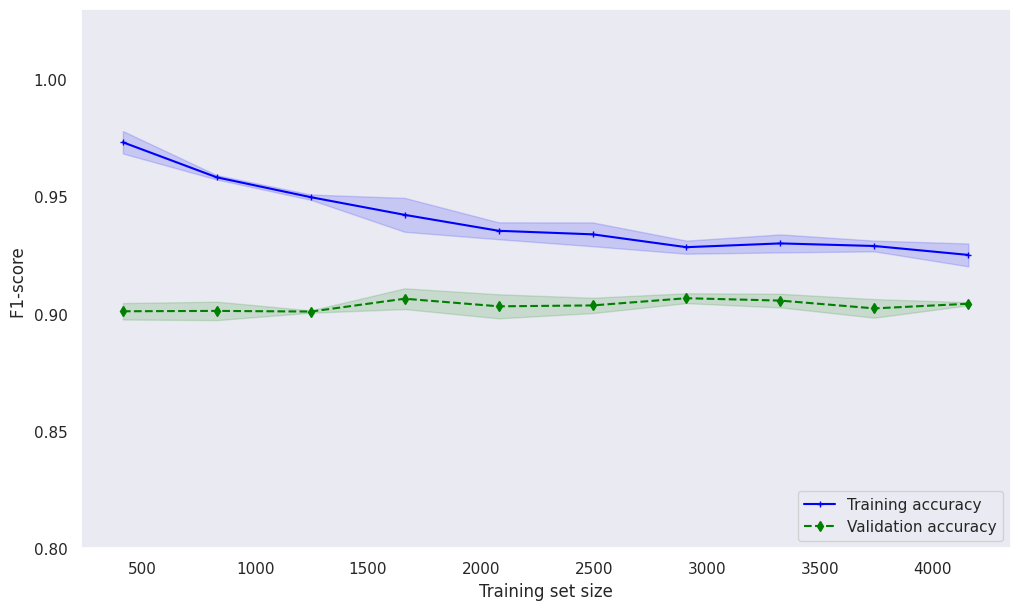

In [ ]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig=plt.figure(figsize=(12,7))
ax = fig.add_subplot()

ax.plot(train_sizes, train_mean,
         color='blue', marker='+',
         markersize=5, label='Training accuracy')

ax.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

ax.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='d', markersize=5,
         label='Validation accuracy')

ax.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Training set size')
ax.set_ylabel('F1-score ')
ax.legend(loc='lower right')
ax.set_ylim([0.80, 1.03])


We plot the confusion matrix, that is a table used to evaluate the performance of a classification algorithm.

Text(0.5, 1.0, 'Confusion Matrix')

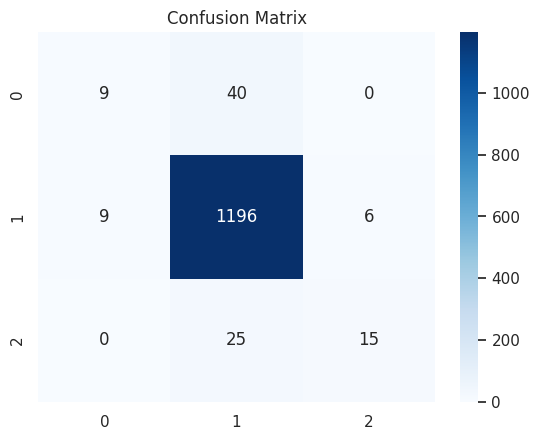

In [ ]:
confusion_matrix_plot = sns.heatmap(
                            data  = confusion_matrix(y_test, y_predicted) ,  
                            annot = True  ,                         
                            cmap  = 'Blues',  
                            fmt   = 'd'                                      
                        )

confusion_matrix_plot.set_title('Confusion Matrix')